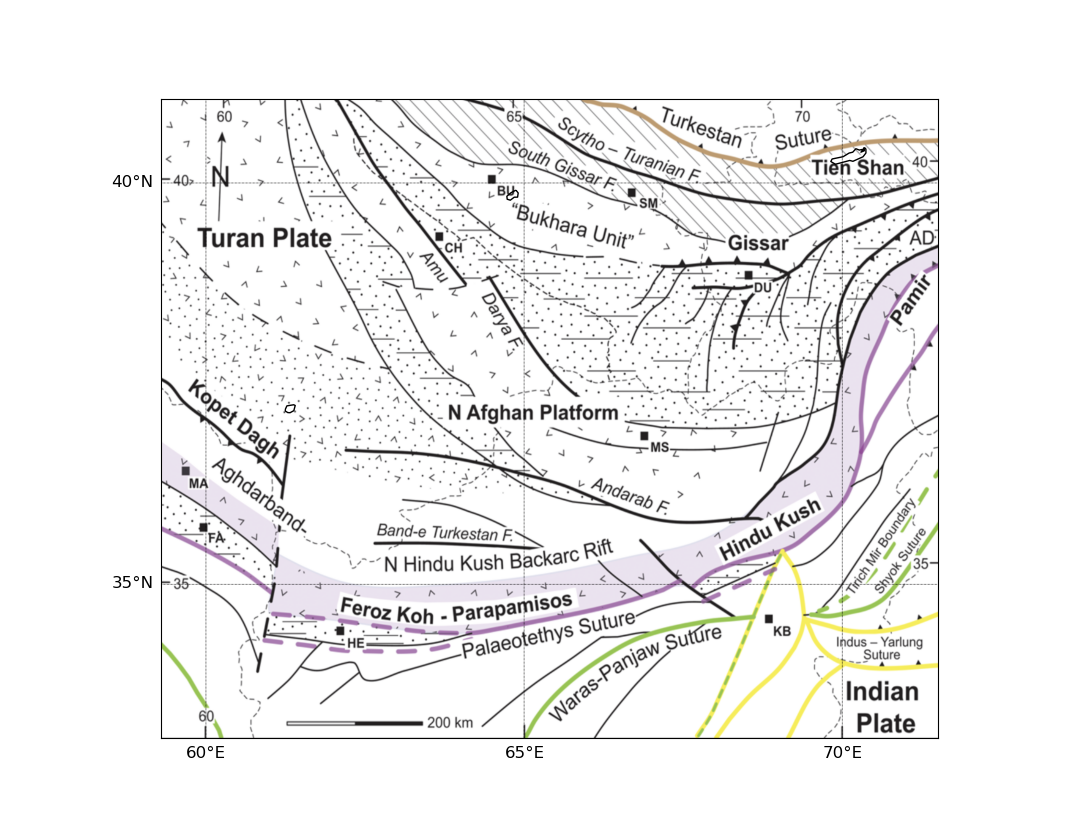

In [6]:
### imports ###
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import matplotlib.image as mpimg 
from mpl_toolkits.basemap import Basemap


### interactive pygmt the function ##
%matplotlib widget

png_path = "figures/Siehl, A., 2017. Figure 3.png"
llcrnrlat = 33
urcrnrlat = 41 
llcrnrlon = 59.3
urcrnrlon = 71.5 
grid_freq = 5


# determine image dimension
img = Image.open(png_path)
width, height = img.size # (width,height) tuple in pixels
DPI_horz, DPI_vert = img.info.get('dpi')

assert DPI_horz == DPI_vert

fig = plt.figure(figsize=(width/DPI_horz, height/DPI_horz))
ax1 = plt.subplot(111)

# creating matplotlib basemap for overlay
m = Basemap(projection='merc', resolution='i',\
                        llcrnrlat=llcrnrlat, urcrnrlat=urcrnrlat,\
                        llcrnrlon=llcrnrlon, urcrnrlon=urcrnrlon)

m.drawcoastlines() # draws coastlines on matplotlib. this makes sure that everything is aligned

# plotting parallels and meridians, annotating axis
parallels = np.arange(-90, 90, grid_freq)
meridians = np.arange(-180, 180, grid_freq)
m.drawparallels(parallels, labels=[1,0,0,0], fontsize=12, linewidth=0.5) # label parallels on right and top
m.drawmeridians(meridians, labels=[0,0,0,1], fontsize=12, linewidth=0.5) # meridians on bottom and left

# plotting pygmt png image in bottom layer
img = mpimg.imread(png_path)
m.imshow(img, origin='upper')


def pos_to_lonlat(x, y):
  lon, lat = m(x, y, inverse=True)
  return lon, lat

pos_fault = [] # in format [[None, None], [x, y], [x, y], ...]
lonlat_fault = []

def onclick(event):
  pos_fault.append([event.xdata, event.ydata])

  lon, lat = pos_to_lonlat(pos_fault[-1][0], pos_fault[-1][1]) # pos[-1] represents last click (list with x, y)
  lonlat_fault.append([lon, lat]) # converts x y to lon lat and appends

  ax1.set_title(f'Click {len(pos_fault)}: {lon}, {lat}') 

cid=fig.canvas.mpl_connect('button_press_event', onclick)

plt.show()


In [7]:
import pandas as pd
## fault saving and printing
fault_pts = np.array(pos_fault[:])

ax1.plot(fault_pts[:,0],fault_pts[:,1], 'r-') # print fault

fault_df = pd.DataFrame(lonlat_fault)
print(fault_df)

# saved as Herat_trace.xy
# based on Siehl, A., 2017. Structural setting and evolution of the Afghan orogenic segment–a review. Geological Society, London, Special Publications, 427(1), pp.57-88.


           0          1
0  61.044683  34.587628
1  62.333394  34.574688
2  63.983573  34.419259
3  66.152379  34.729827
4  67.111055  34.897566
5  67.378226  35.077826


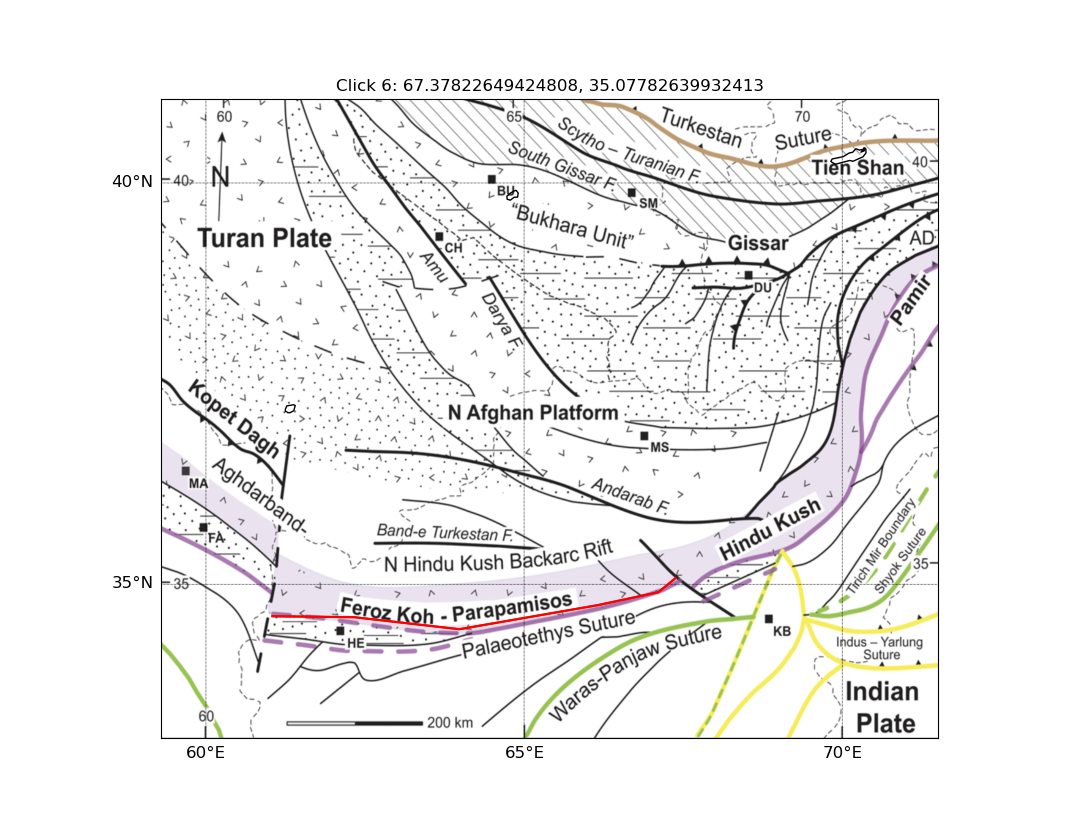

In [8]:
fault_pts = np.array(pos_fault[:])
# fault_pts = np.append(fault_pts,[fault_pts[0]], axis=0) # to close our polygon when plotting. axis=0 specify along rows

ax1.plot(fault_pts[:,0],fault_pts[:,1], 'r-')
plt.show()